In [1]:
import pandas as pd
import numpy as np
from modulos.data_load import load, coins
import matplotlib.pyplot as plt
import seaborn as sns

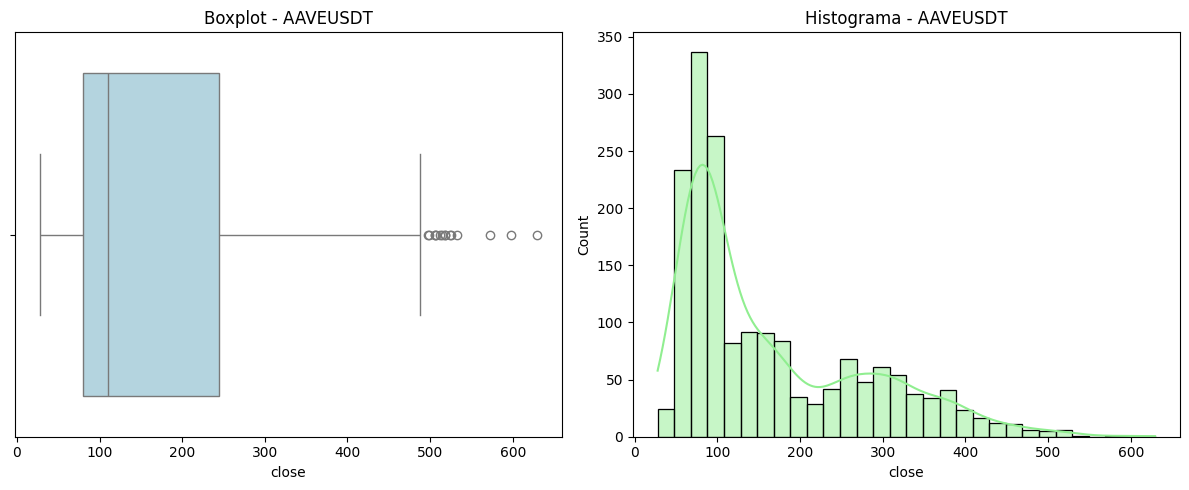

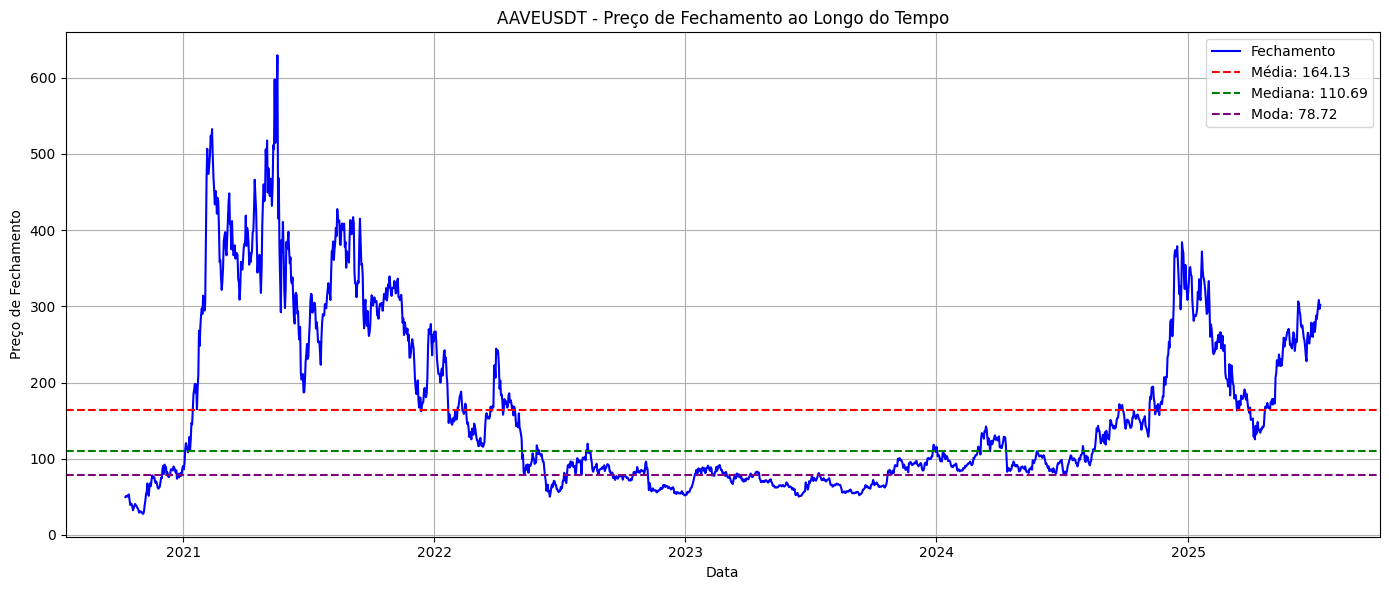

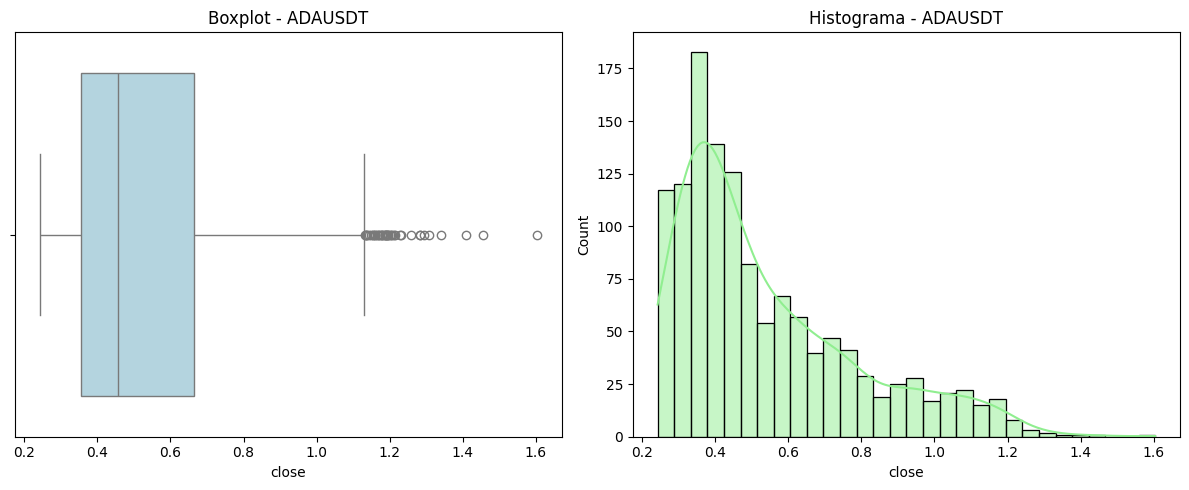

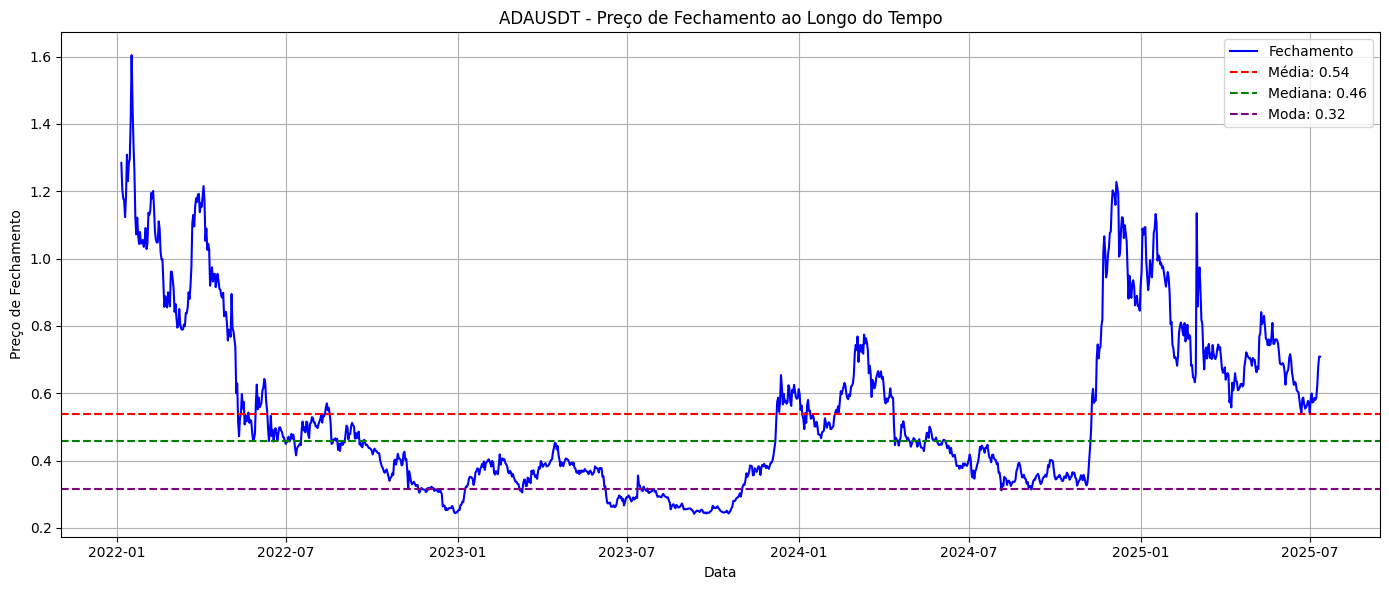

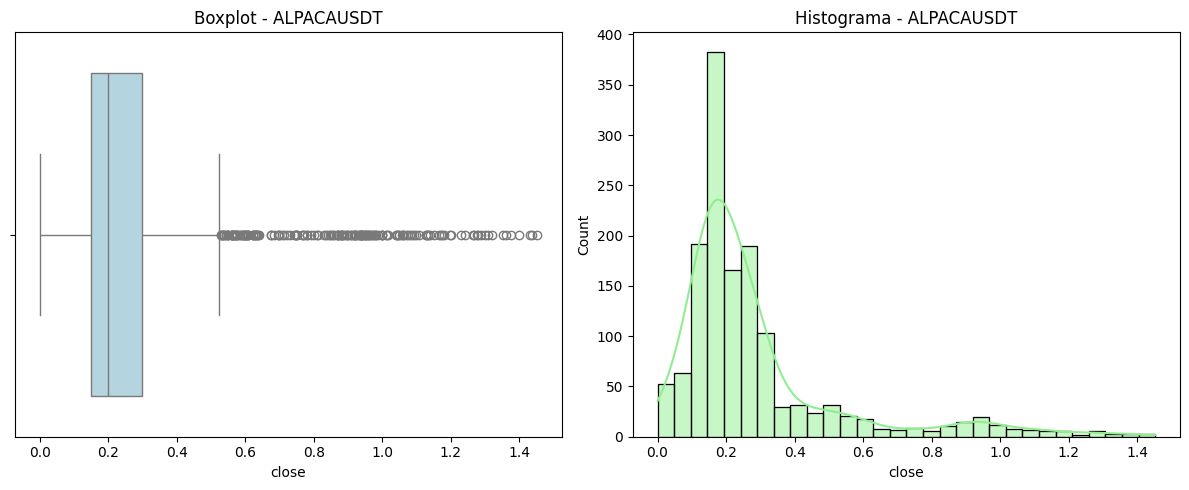

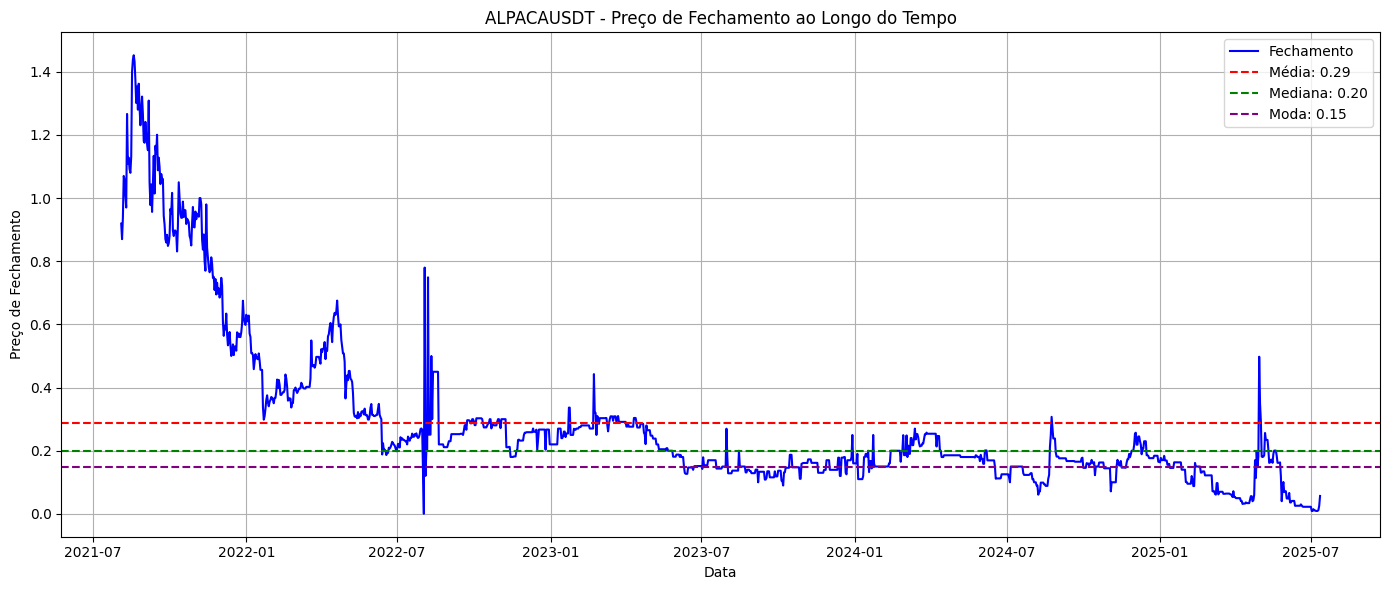

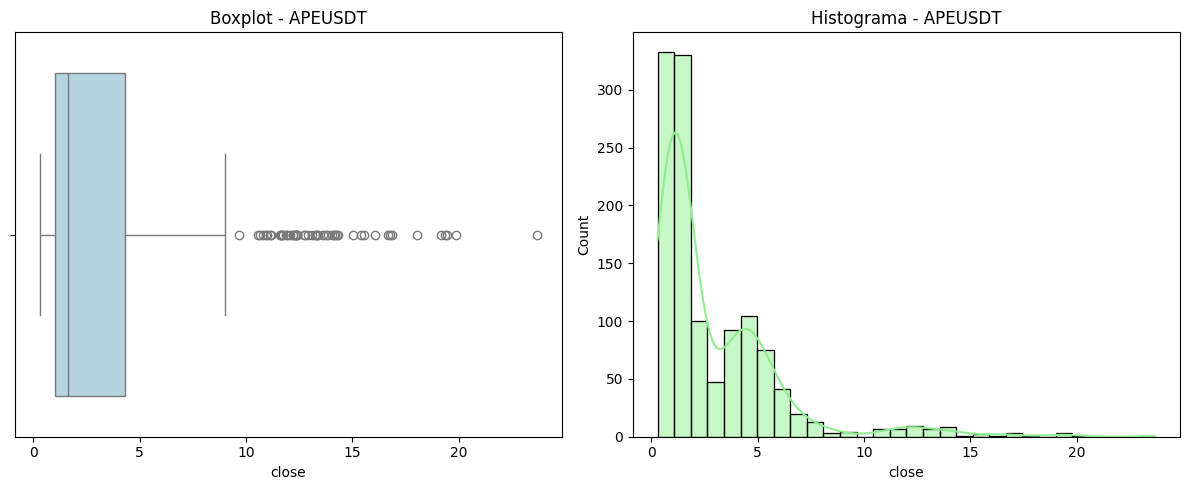

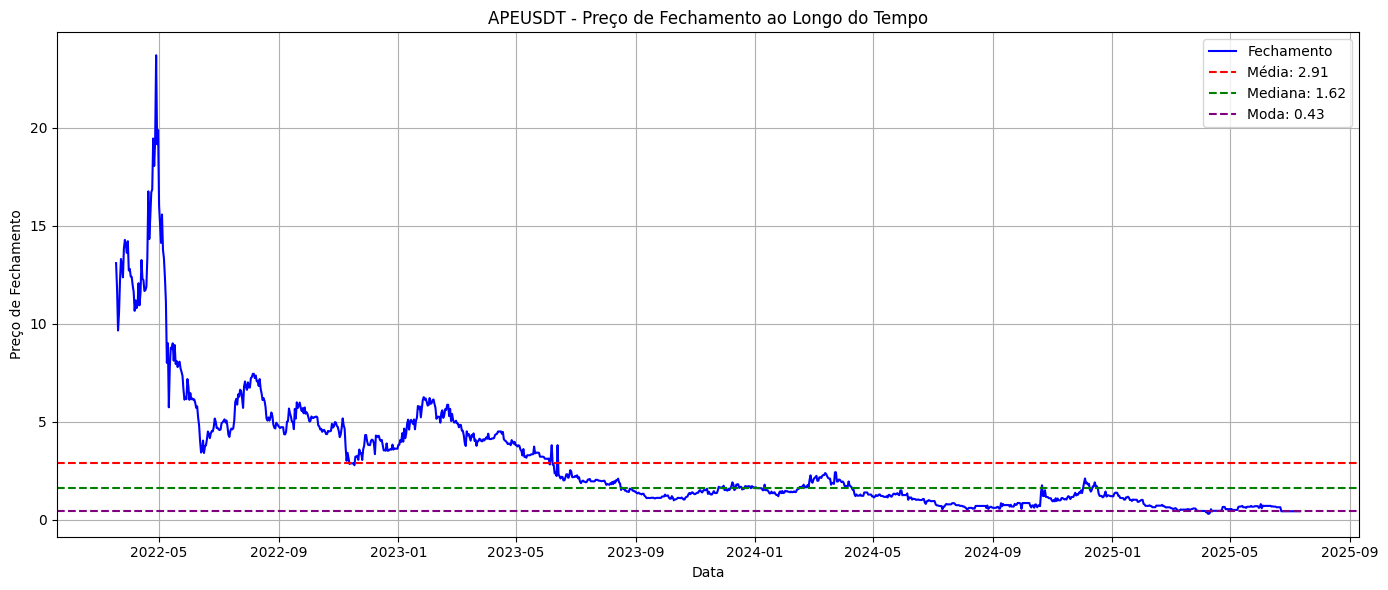

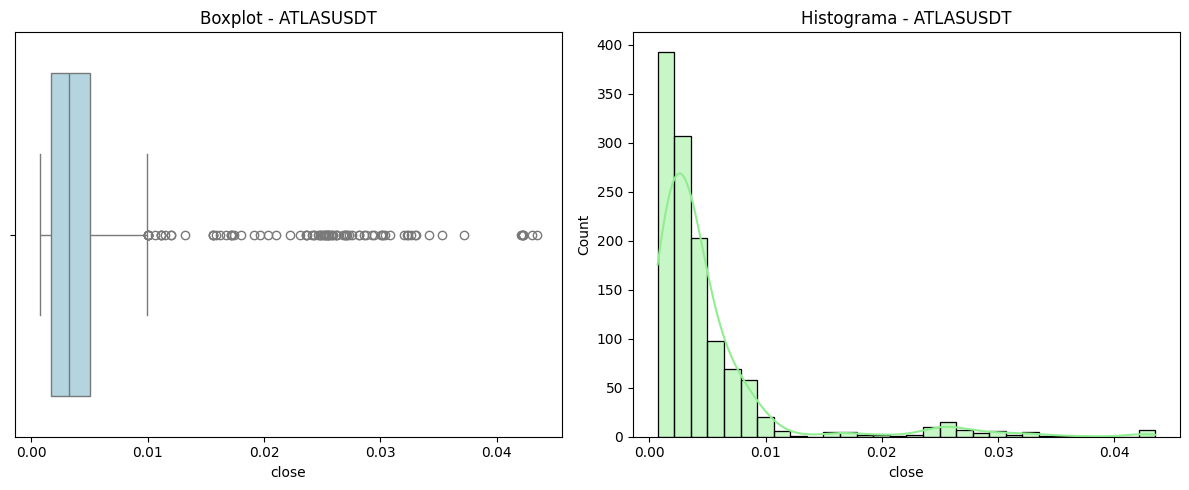

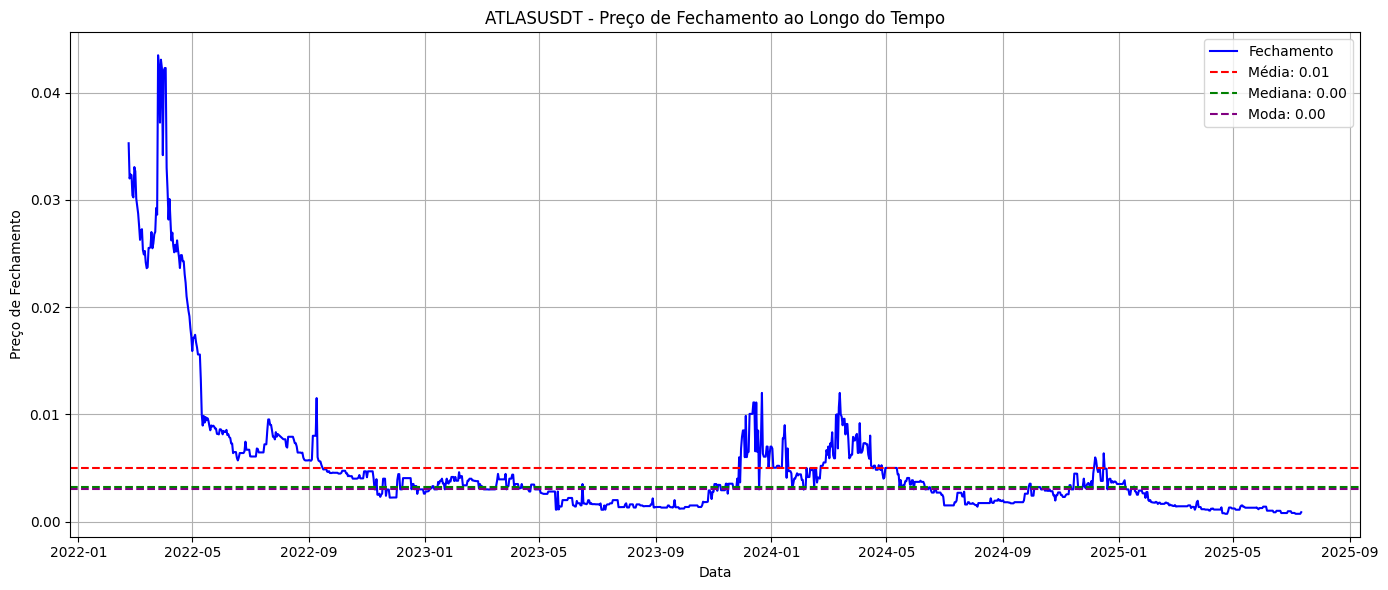

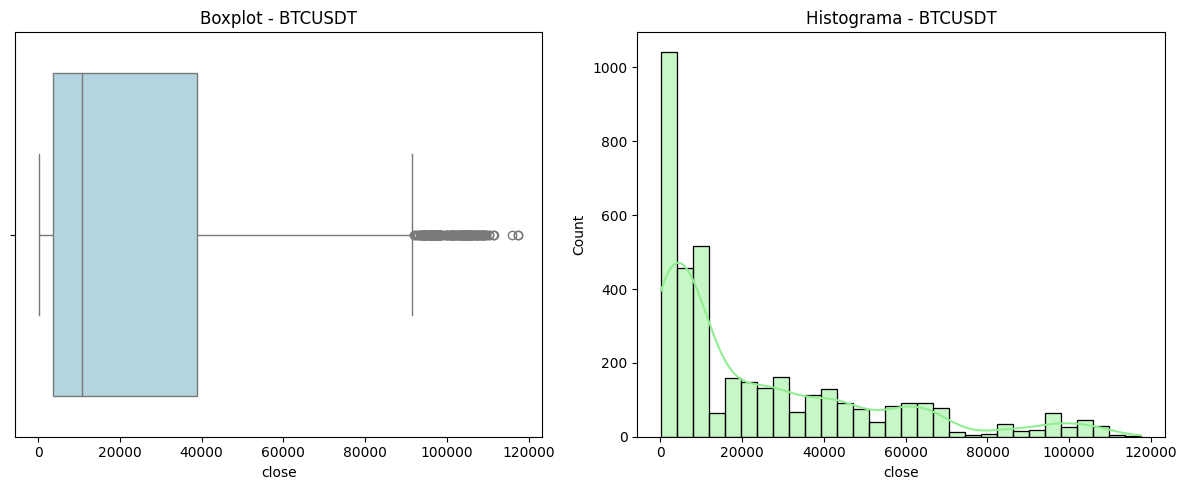

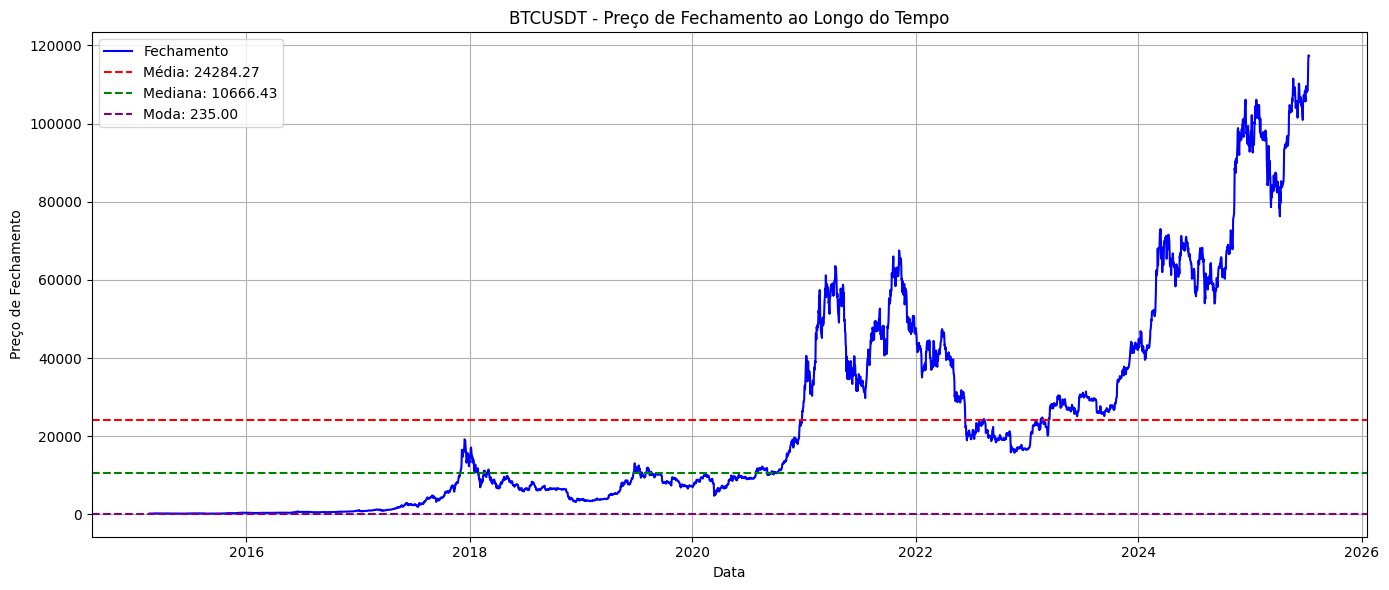

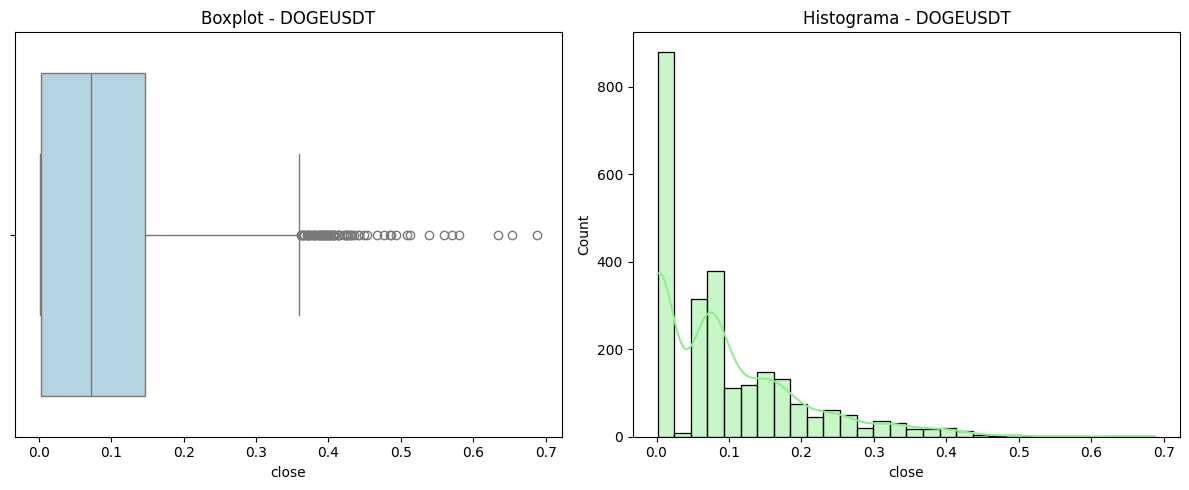

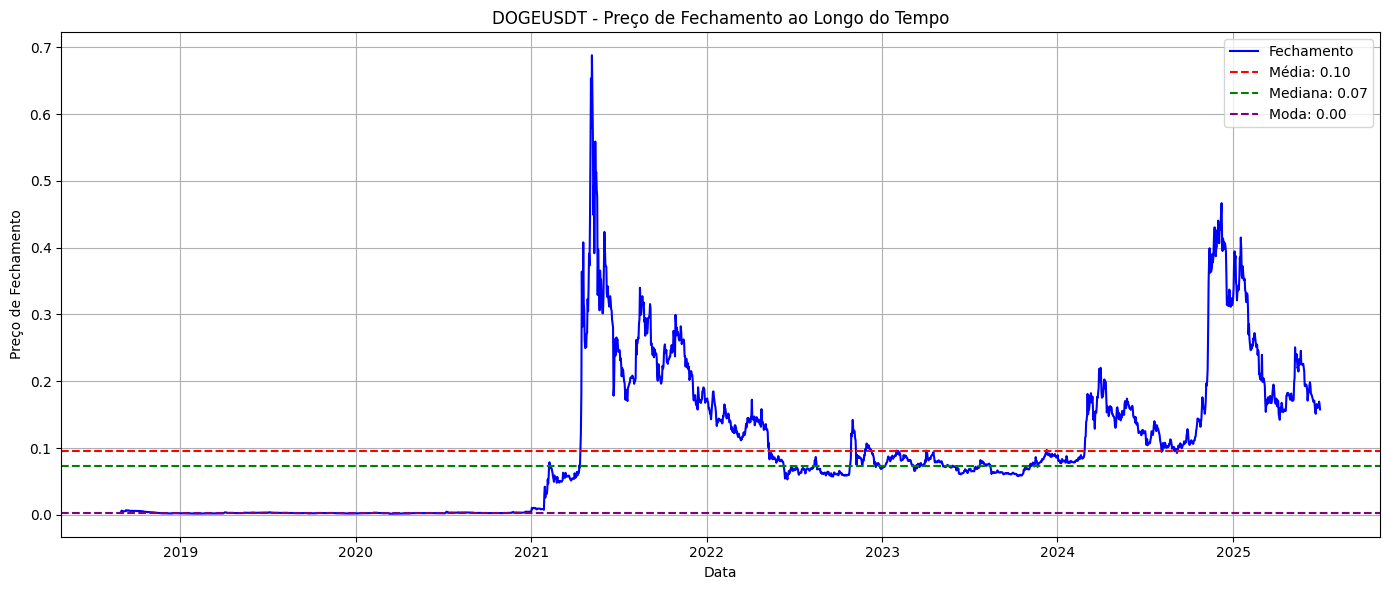

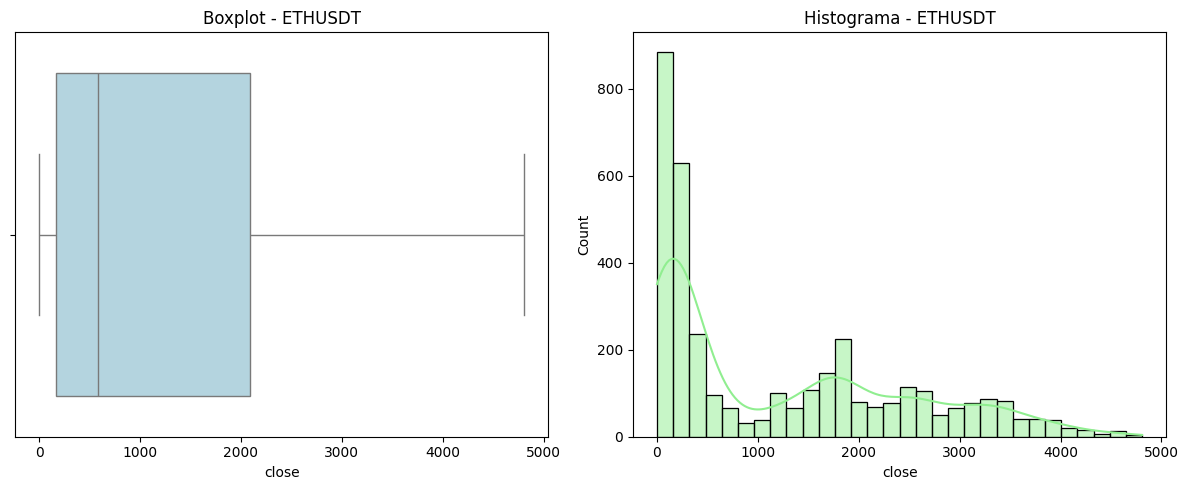

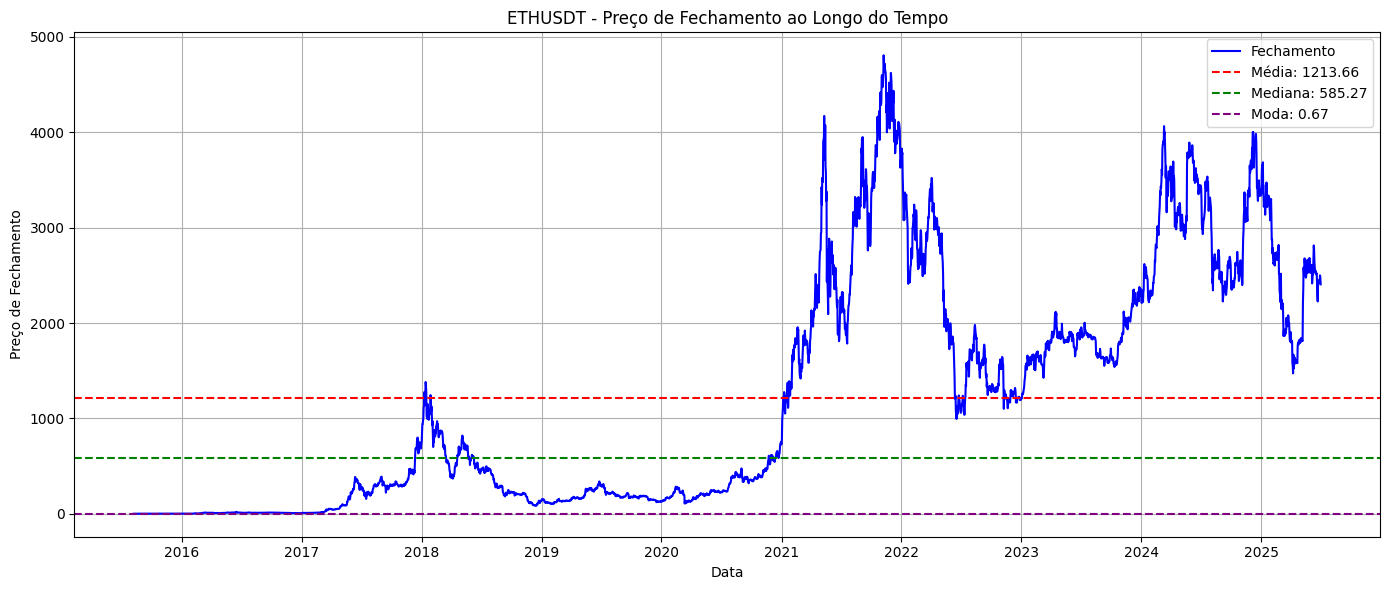

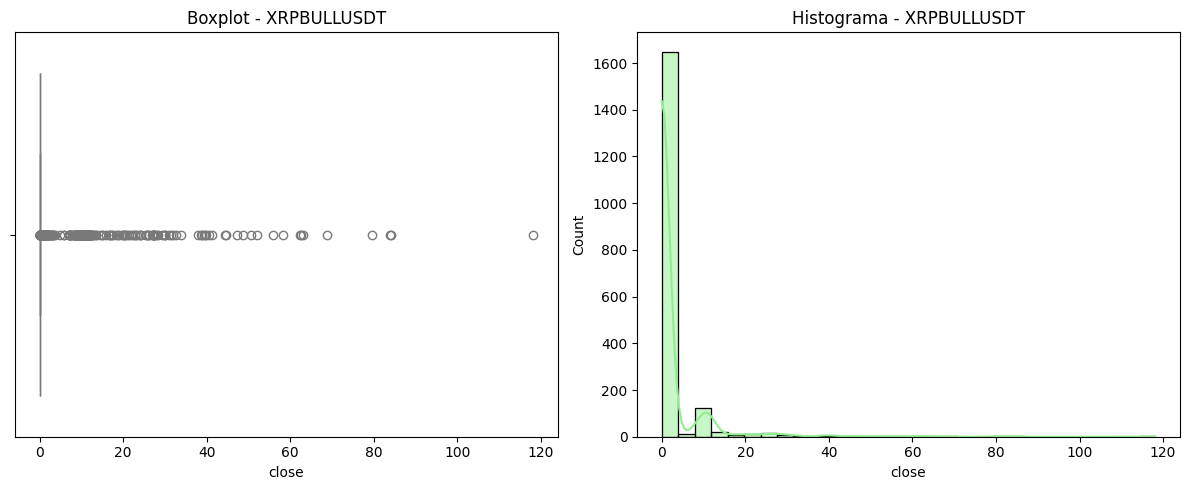

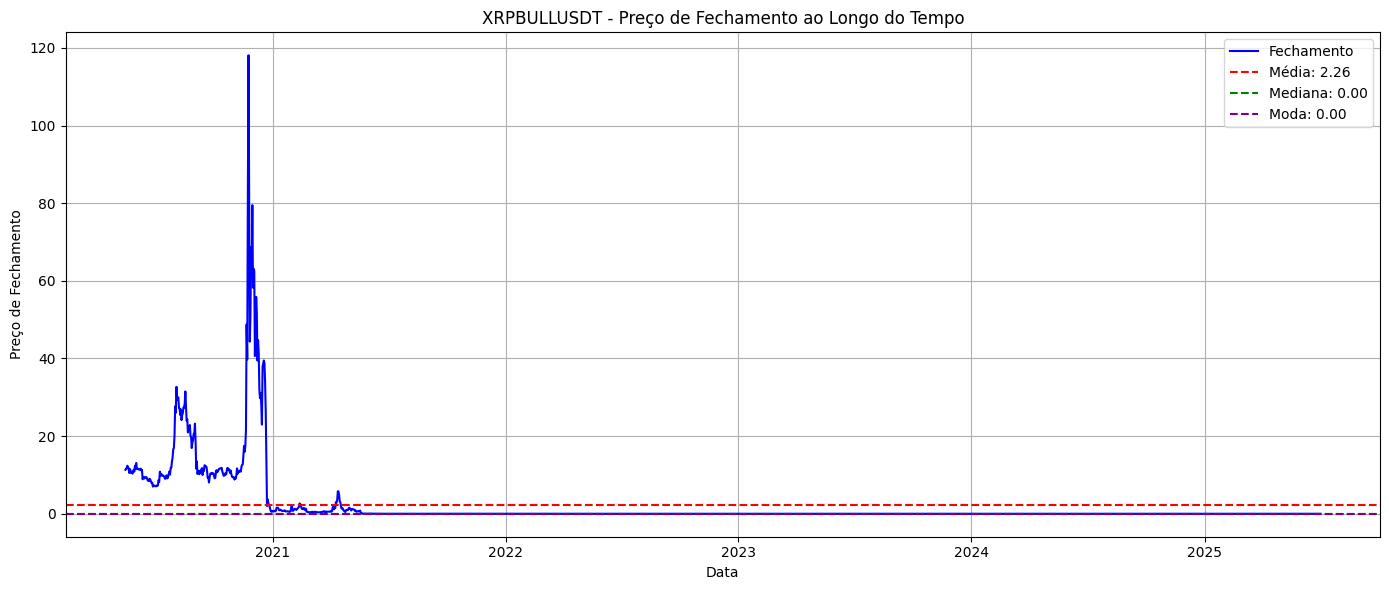

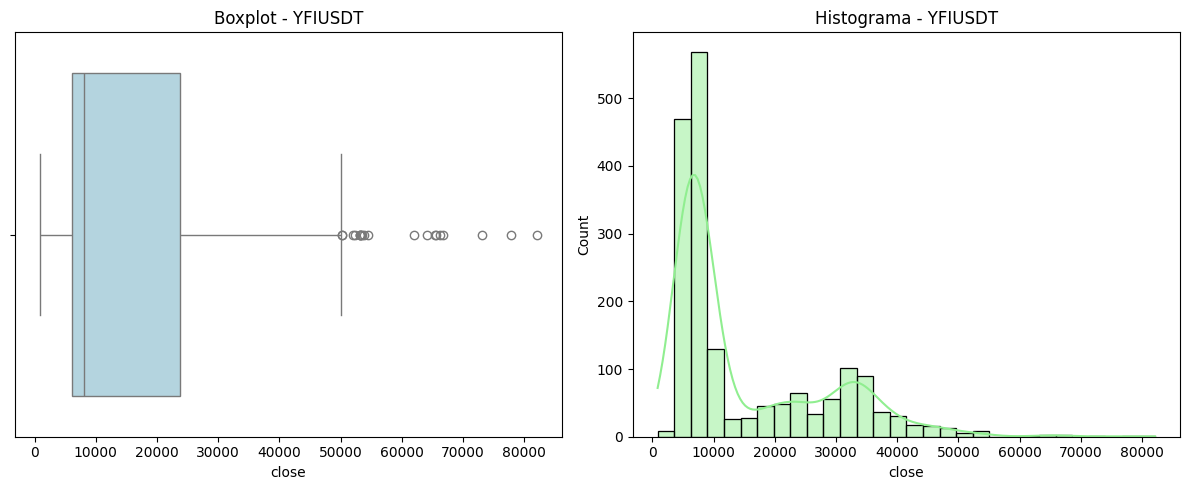

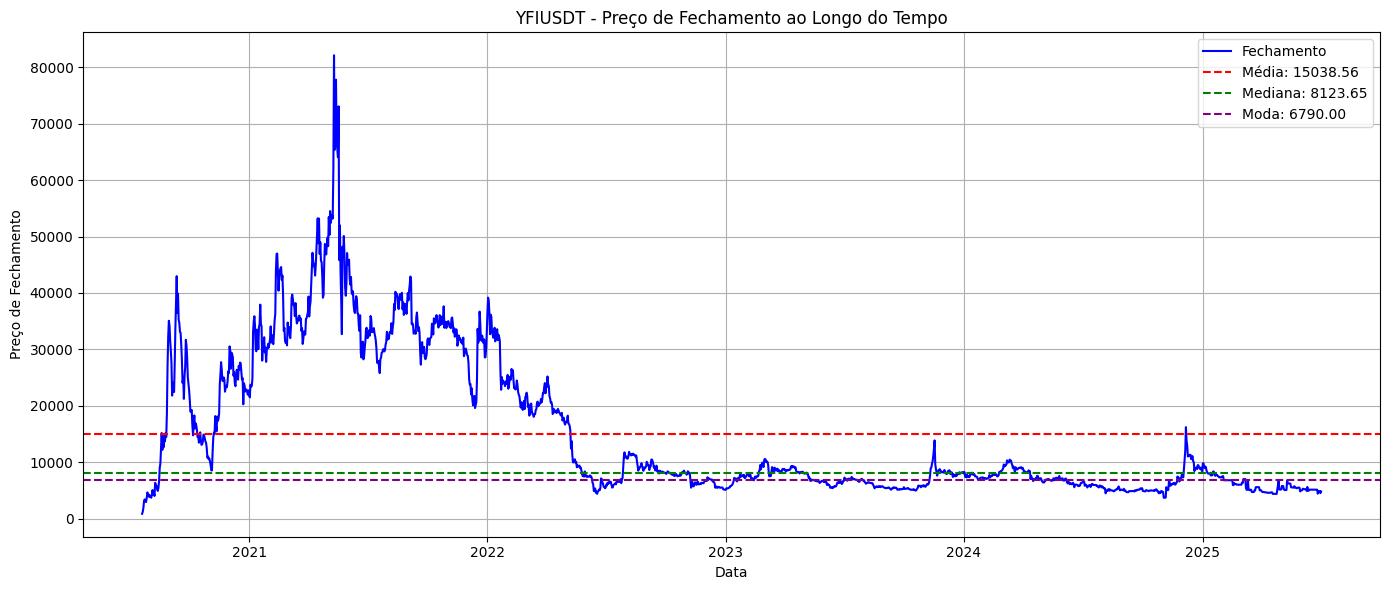

          coin          mean           std           var  coef_var
8  XRPBULLUSDT      2.257777      8.013935  6.422315e+01  3.549480
4    ATLASUSDT      0.005018      0.006291  3.957876e-05  1.253823
5      BTCUSDT  24284.269589  27495.043654  7.559774e+08  1.132216
6     DOGEUSDT      0.096166      0.103870  1.078899e-02  1.080110
3      APEUSDT      2.907946      3.023640  9.142396e+00  1.039785
7      ETHUSDT   1213.663918   1238.125421  1.532955e+06  1.020155
2   ALPACAUSDT      0.287184      0.251387  6.319542e-02  0.875352
9      YFIUSDT  15038.560749  12763.483579  1.629065e+08  0.848717
0     AAVEUSDT    164.129439    112.548796  1.266723e+04  0.685732
1      ADAUSDT      0.538635      0.249159  6.208041e-02  0.462576


In [3]:
results = []

for i, coin in enumerate(coins, start=1):
    df = load(coin).copy()

    # Etapa A: Medidas resumo e dispersão
    resumo = df['close'].describe()
    variancia = df['close'].var()
    desvio_padrao = df['close'].std()
    coef_var = desvio_padrao / df['close'].mean()

    results.append({
        'coin': coin,
        'mean': resumo['mean'],
        'median': resumo['50%'],
        'mode': df['close'].mode().iloc[0] if not df['close'].mode().empty else None,
        'std': desvio_padrao,
        'var': variancia,
        'coef_var': coef_var
    })

    # Etapa B: Boxplot e Histograma
    plt.figure(figsize=(12, 5))
    
    # Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df['close'], color='lightblue')
    plt.title(f'Boxplot - {coin}')

    # Histograma
    plt.subplot(1, 2, 2)
    sns.histplot(df['close'], bins=30, kde=True, color='lightgreen')
    plt.title(f'Histograma - {coin}')
    plt.tight_layout()
    plt.savefig(f"figures/COIN{i}_{coin}_boxplot_hist.png")
    plt.show()

    # Etapa D: Gráfico de linha com média, mediana, moda
    media = resumo['mean']
    mediana = resumo['50%']
    moda = df['close'].mode().iloc[0] if not df['close'].mode().empty else None

    plt.figure(figsize=(14, 6))
    plt.plot(df['date'], df['close'], label='Fechamento', color='blue')
    plt.axhline(media, color='red', linestyle='--', label=f'Média: {media:.2f}')
    plt.axhline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')
    if moda is not None:
        plt.axhline(moda, color='purple', linestyle='--', label=f'Moda: {moda:.2f}')
    plt.title(f'{coin} - Preço de Fechamento ao Longo do Tempo')
    plt.xlabel("Data")
    plt.ylabel("Preço de Fechamento")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/COIN{i}_{coin}_closing_price.png")
    plt.show()

#Etapa C: Comparação entre moedas
df_disp = pd.DataFrame(results)
print(df_disp[['coin', 'mean', 'std', 'var', 'coef_var']].sort_values('coef_var', ascending=False))


